In [70]:
import pandas as pd
import matplotlib.pyplot as pit

# Đọc file
df = pd.read_csv('../api/used_cars.csv')


In [61]:
# Số lượng giá trị null hoặc không có giá trị

df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [62]:
# Xóa các hàng có các giá trị là null hoặc không có giá trị

df.dropna(axis=1, inplace=True)

In [63]:
# Kiểm tra lại các giá trị null hoặc không có giá trị

df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
engine          0
transmission    0
ext_col         0
int_col         0
price           0
dtype: int64

In [64]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [65]:
df.head()

,brand,model,model_year,milage,engine,transmission,ext_col,int_col,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",3.5 Liter DOHC,Automatic,Blue,Black,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,"$34,999"


In [71]:
# Xử lý giá tiền của xe từ chuỗi thành số

df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

# Xử lý số dặm xe đã đi

df['milage'] = (
    df['milage']
    .str.replace(',', '', regex=False)
    .str.replace('mi.', '', regex=False)
    .astype(int)
)

df['milage']



0       51000
1       34742
2       22372
3       88900
4        9835
        ...  
4004      714
4005    10900
4006     2116
4007    33000
4008    43000
Name: milage, Length: 4009, dtype: int64

In [72]:
# Hiển thị các giá trị cơ bản trong dataframe
df.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


Index(['Ford', 'BMW', 'Mercedes-Benz', 'Chevrolet', 'Porsche'], dtype='str', name='brand')


Text(0.5, 1.0, 'Biểu đồ số lượng xe các năm của các hãng top đầu')

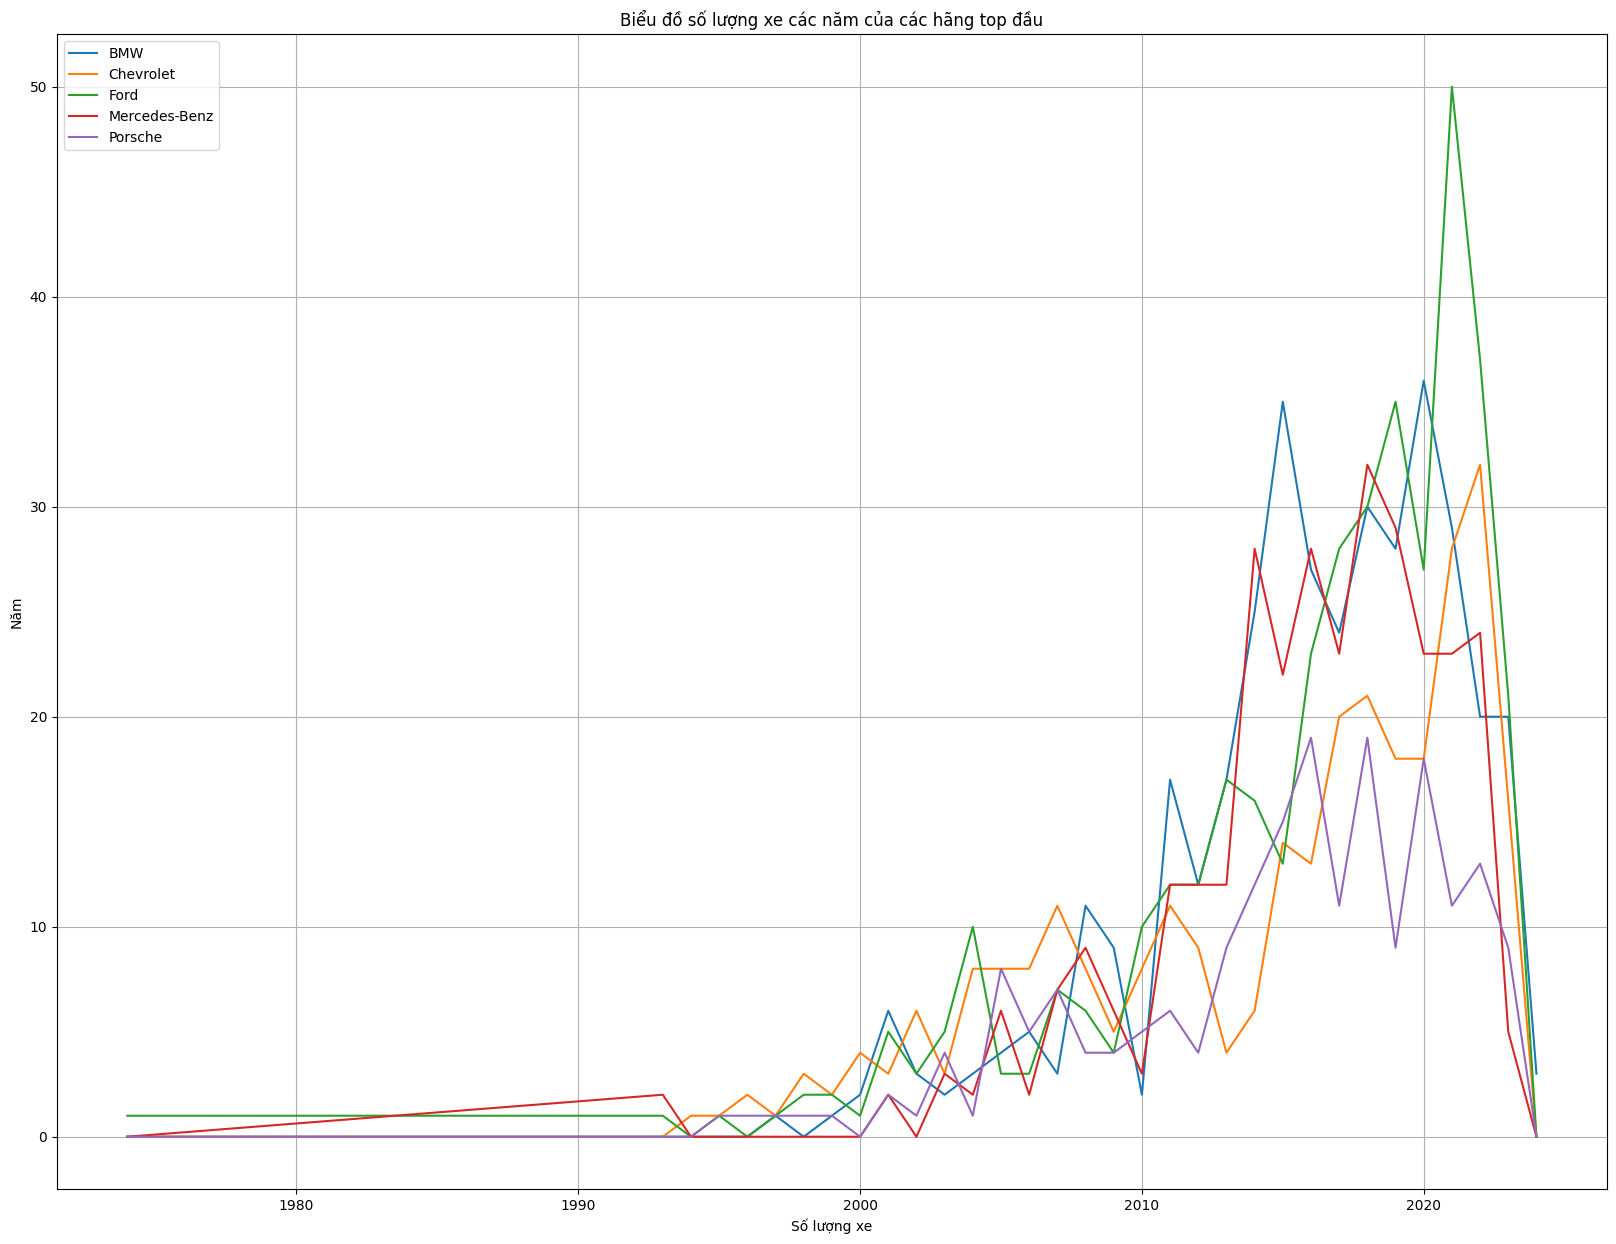

In [67]:
# Biều đồ đường: Dùng để biểu diễn tổng số xe của hãng đó trong các năm

top_brand = df['brand'].value_counts().head().index

print(top_brand)
df_top_brand = df[df['brand'].isin(top_brand)]
pivot_df = df_top_brand.pivot_table(index='model_year', columns='brand', values='model', aggfunc='count', fill_value=0)

pit.figure(figsize=(20, 15))
for brand in pivot_df.columns:
    pit.plot(pivot_df.index, pivot_df[brand], label=brand)

pit.xlabel('Số lượng xe')
pit.ylabel('Năm')
pit.legend()
pit.grid()
pit.title('Biểu đồ số lượng xe các năm của các hãng top đầu')

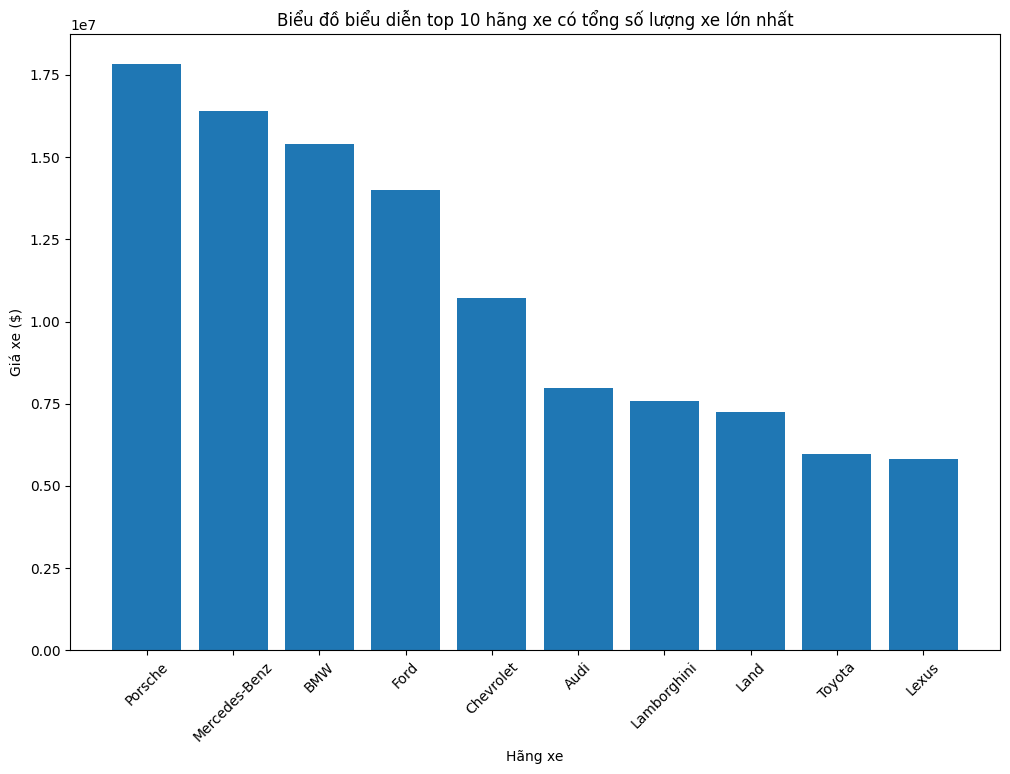

In [81]:
# Biểu đồ cột: Dùng để biểu diễn top 10 hãng xe có tổng số lượng xe lớn nhất

df_sum_brand = df[['brand', 'price']].groupby('brand').sum()
df_sum_brand = df_sum_brand.sort_values(by='price', ascending=False).head(10)
df_sum_brand

pit.figure(figsize=(12, 8))
pit.bar(x=df_sum_brand.index, height=df_sum_brand['price'])
pit.xticks(rotation=45)
pit.title('Biểu đồ biểu diễn top 10 hãng xe có tổng số lượng xe lớn nhất')
pit.xlabel('Hãng xe')
pit.ylabel('Giá xe ($)')
pit.show()


In [ ]:
# Biều đồ biểu thị giá trị ngoại lai (Box plot)

pit.boxplot(df['price'], patch_artist=True)
pit.title("Price Distribution")
pit.ylabel("Price")
pit.show()

pit.boxplot(df['milage'], patch_artist=True)
pit.title("Milage Distribution")
pit.ylabel("Milage")
pit.show()


In [91]:
from sklearn.preprocessing import LabelEncoder

# Chuyển đổi dữ liệu màu và nhiên liệu thành dạng để phân tích

    # Label encoding

        # Đối với màu xe



ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Biểu đồ biẻu diễn mối quan hệ giữa số dặm đi, số năm sản suát, màu, nhiên liệu và giá xe

